In [1]:
from itertools import product
from multiprocessing import get_context
from time import perf_counter

import colormaps
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as cs
import polars_st as st
import wavebreaking as wb
import xarray as xr
from contourpy import contour_generator
from jetutils.data import smooth
from jetutils.definitions import (
    DATADIR,
    RADIUS,
    Timer,
    circular_mean,
    get_index_columns,
    map_maybe_parallel,
    to_expr,
    weighted_mean_pl,
)
from jetutils.geospatial import (
    detect_contours,
    detect_overturnings,
    detect_streamers,
    event_props,
    haversine,
    inner_detect_contours,
    jet_integral_haversine,
    join_wrapper,
    sjoin_to_grid,
    sort_by_index_then_newindex,
    to_xarray_sjoin,
    signed_difflon,
    difflon
)
from tqdm import tqdm, trange

%load_ext IPython.extensions.autoreload
%autoreload 2
%matplotlib inline

In [362]:
zeta = (
    xr.open_dataarray(
        "/Users/bandelol/Documents/code_local/data/Henrik_data/zeta300ctrl_sample.nc"
    )
    .sel(lev=30000, lat=slice(10, 80))
    .load()
    .reset_coords({"lev", "loni", "lati"}, drop=True)
    .rename("zeta")
    * 1e5
)

zeta = smooth(zeta, {"lon": ("win", 7), "lat": ("win", 7)})
da = zeta
mflux = - (
    xr.open_dataarray(
        "/Users/bandelol/Documents/code_local/data/Henrik_data/mflux300ctrl_sample.nc"
    )
    .load()
    .rename("mflux")
)

mflux = smooth(mflux, {"lon": ("win", 5), "lat": ("win", 5)})
processes = 10
ctx = None
levels = [9]
repeat_lons = 180


with Timer():
    contours = detect_contours(zeta, levels, repeat_lons, processes)
with Timer():
    overturnings = detect_overturnings(contours, max_difflon=2.4, min_lon_ext=10)
with Timer():
    overturnings, ot_on_grid = event_props(overturnings, [zeta, mflux])
    
overturnings_nogeo = overturnings.drop("geometry").explode("points", "side").explode("points").with_columns(lon=pl.col("points").arr.get(0), lat=pl.col("points").arr.get(1))
with Timer():
    ot_da = to_xarray_sjoin(zeta, overturnings, ot_on_grid)
with Timer():
    streamers = detect_streamers(contours, max_realdist=8e5, min_contourdist=1.5e6, max_contourdist=2e8, min_ratio=8)
    
with Timer():
    streamers, st_on_grid = event_props(streamers, [zeta, mflux])
streamers_nogeo = streamers.drop("geometry").explode("points", "side").explode("points").with_columns(lon=pl.col("points").arr.get(0), lat=pl.col("points").arr.get(1))
# with Timer():
#     st_da = to_xarray_sjoin(zeta, streamers, st_on_grid)
    
    
# try:
#     contours_sev = gpd.read_parquet("contours_severin.parquet")
# except FileNotFoundError:
#     contours_sev = wb.calculate_contours(zeta, levels, periodic_add=120, original_coordinates=False)
#     contours_sev.to_parquet("contours_severin.parquet")

# try:
#     overturnings_sev = gpd.read_parquet("test_aavo_severin.parquet")
# except FileNotFoundError:
#     overturnings_sev = wb.calculate_overturnings(zeta, levels, contours=contours_sev)
#     overturnings_sev.to_parquet("test_aavo_severin.parquet")
# ot_da_sev = wb.to_xarray(zeta, overturnings_sev)

# try:
#     streamers_sev = gpd.read_parquet("test_streamers_severin.parquet")
# except FileNotFoundError:
#     streamers_sev = wb.calculate_streamers(zeta, levels, contours=contours_sev)
#     streamers_sev.to_parquet("test_streamers_severin.parquet")
# st_da_sev = wb.to_xarray(zeta, streamers_sev)

Elapsed time: 3.8637 seconds
Elapsed time: 0.8640 seconds
Elapsed time: 13.1076 seconds
Elapsed time: 0.4246 seconds
Elapsed time: 9.3054 seconds
Elapsed time: 14.2704 seconds


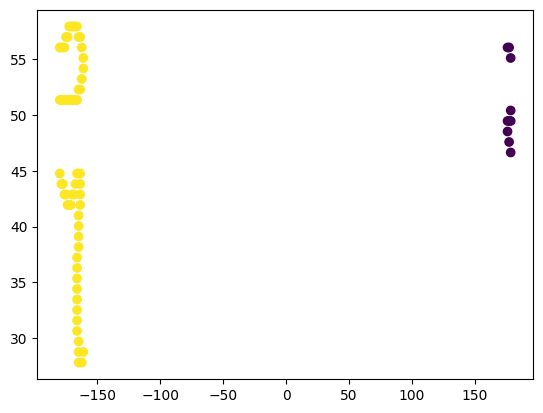

In [422]:
huh = overturnings_nogeo.filter(pl.col("side").mean().over("time", "level", "index") > 0)

for indexer, subdf in huh.group_by("time", "level", "index"):
    plt.scatter(subdf["lon"], subdf["lat"], c=subdf["side"], vmin=0, vmax=1)
    break

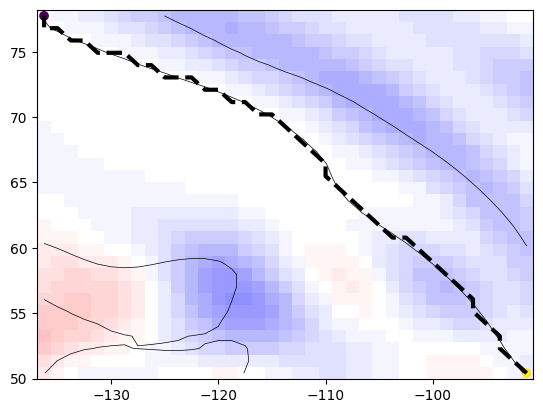

In [6]:
index_columns = ["time", "level", "index"]

for indexer, st_nogeo in streamers_nogeo.group_by(index_columns):
    time, _, _ = indexer
    lo, la = st_nogeo["lon", "lat"]
    low, loe, law, lae = lo.first(), lo.last(), la.first(), la.last()
    
    da1 = mflux.sel(time=time, lon=slice(lo.min(), lo.max()), lat=slice(la.min(), la.max()))
    da2 = zeta.sel(time=time, lon=slice(lo.min(), lo.max()), lat=slice(la.min(), la.max()))
    lon, lat = da1.lon.values, da1.lat.values
    plt.pcolormesh(lon, lat, da1, cmap=colormaps.BlWhRe, norm=Normalize(-800, 800))
    plt.contour(lon, lat, da2, levels=[9], colors="black", linewidths=0.5)
    # is_anti = st_nogeo["orientation"].first() == "anticyclonic"
    # color = "blue" if is_anti else "red"
    mflu = st_nogeo["mflux"].first()
    ls = "dotted" if mflu >= 0 else "dashed"
    plt.plot(lo, la, color="black", ls=ls, lw=3)
    plt.scatter([loe, low], [lae, law], c=np.arange(2))
    break

In [570]:
max_realdist: float = 7e5
min_contourdist: float = 1.5e6
max_contourdist: float = 2e7
min_ratio: float = 9
    
index_columns = get_index_columns(contours, ["member", "time", "level", "contour"])

ds = haversine(
    "lon",
    "lat",
    pl.col("lon").shift(),
    pl.col("lat").shift(),
)
ds = ds.fill_null(0.0)
s = ds.cum_sum()
contours = contours.with_columns(
    s=s.over(index_columns),
    max_s=s.max().over(index_columns),
    max_n=pl.col("index").max().over(index_columns),
).with_columns(cs.signed_integer().cast(pl.Int32()))

contourslazy = contours.lazy()

dist_forward = pl.col("s_right") - pl.col("s")
dist_backward = pl.col("max_s") - (pl.col("s_right") - pl.col("s"))
dist2 = pl.min_horizontal(dist_forward, dist_backward)
forward = dist_forward <= dist_backward

streamers = (
    contourslazy.join(
        contourslazy.select(*index_columns, "index", "lon", "lat", "s"),
        on=index_columns,
    )
    .filter(pl.col("index_right") > pl.col("index"))
    .with_columns(
        dist1=haversine("lon", "lat", "lon_right", "lat_right"),
        dist2=dist2,
        forward=forward,
        ratio=dist2 / haversine("lon", "lat", "lon_right", "lat_right")
    )
    .filter(
        pl.col("dist1") < max_realdist,
        pl.col("dist2") > min_contourdist,
        pl.col("dist2") < max_contourdist,
        pl.col("ratio") > min_ratio,
        pl.col("forward") | (~pl.col("cyclic")),
    )
    .collect(streaming=True)
)

max_ratio = pl.col("dist1") == pl.col("dist1").min()
max_ratio_left = max_ratio.over(
    [*index_columns, "index_right"]
)
max_ratio_right = max_ratio.over(
    [*index_columns, "index"]
)

range_ = pl.int_ranges(pl.col("index"), pl.col("index_right") + 1)
other_range = pl.int_ranges(
    pl.col("index_right"), pl.col("index") + 1 + pl.col("max_n")
) % pl.col("max_n")
range_ = pl.when("forward").then(range_).otherwise(other_range)

streamers = (
    streamers[*index_columns, "index", "index_right", "forward", "max_n", "dist1"]
    .filter(max_ratio_right)
    .filter(max_ratio_left)
    .with_columns(range=range_)
    .sort(*index_columns, "index")
)


to_drop = (
    streamers.join(streamers, on=index_columns, suffix="_other", how="left")
    .filter(pl.col("range").list.len() < pl.col("range_other").list.len())
    .with_columns(
        drop=pl.col("range_other").list.contains(pl.col("index"))
        & pl.col("range_other").list.contains(pl.col("index_right"))
    )
    .group_by([*index_columns, "index", "index_right"])
    .agg(pl.col("drop").any())
)

streamers = (
    streamers.join(
        to_drop,
        on=[*index_columns, "index", "index_right"],
        how="left",
    )
    .filter(~pl.col("drop").fill_null(False))
    .drop("drop")
    .with_columns(subindex=pl.int_range(pl.len()).over(index_columns))
)
l1 = pl.col("range").list.len()
l2 = pl.col("range_other").list.len()
linter = pl.col("range").list.set_intersection(
    pl.col("range_other")
).list.len() / pl.min_horizontal(l1, l2)

index = (
    pl.when("forward").then(pl.col("index").min()).otherwise(pl.col("index").max())
)
index_right = (
    pl.when("forward")
    .then(pl.col("index_right").max())
    .otherwise(pl.col("index_right").min())
)
    
streamers = (
    streamers[
        *index_columns,
        "range",
        "subindex",
        "index",
        "index_right",
        "forward",
        "max_n",
    ]
    .join(
        streamers[*index_columns, "range", "subindex", "index", "index_right"],
        on=index_columns,
        how="left",
        suffix="_other",
    )
    .with_columns(l1=l1, l2=l2)
    .with_columns(linter=linter)
    .filter(pl.col("linter") > 0.8)
    .group_by(*index_columns, "index", "index_right", "forward", "subindex")
    .agg(
        minio=pl.col("index_other").min(),
        maxio=pl.col("index_other").max(),
        miniro=pl.col("index_right_other").min(),
        maxiro=pl.col("index_right_other").max(),
        max_n=pl.col("max_n").first(),
    )
    .with_columns(
        index=pl.when("forward").then("minio").otherwise("maxio"),
        index_right=pl.when("forward").then("maxiro").otherwise("miniro"),
    )
    .drop(["minio", "maxio", "miniro", "maxiro"])
    .unique([*index_columns, "index", "index_right", "forward"])
    .sort(*index_columns, "index", "index_right")
    .with_columns(subindex=pl.int_range(pl.len()).over(index_columns))
    .with_columns(range=range_)
)

index = (
    pl.when("forward").then(pl.col("index").min()).otherwise(pl.col("index").max())
)
index_right = (
    pl.when("forward")
    .then(pl.col("index_right").max())
    .otherwise(pl.col("index_right").min())
)

streamers = (
    streamers
    .explode("range")
    .unique([*index_columns, "range"])
    .group_by([*index_columns, "forward", "subindex"])
    .agg(
        pl.col("max_n").first(),
        index=index.first(),
        index_right=index_right.first(),
    )
    .with_columns(range=range_)
    .drop("index", "index_right", "max_n")
    .explode("range")
    .with_columns(cs.signed_integer().cast(pl.Int32()))
    .rename({"range": "index"})
    .join(
        contours.drop("s", "len", "max_s", "max_n", "cyclic"),
        on=[*index_columns, "index"],
    )
    .sort(*index_columns, "forward", "subindex", "index")
    .drop("index")
)

index = pl.concat_arr(
    pl.col("contour").cast(pl.UInt32()), pl.col("subindex").cast(pl.UInt32())
).rle_id()
index_columns.remove("contour")
index = index.over(index_columns)
streamers = streamers.with_columns(index=index)

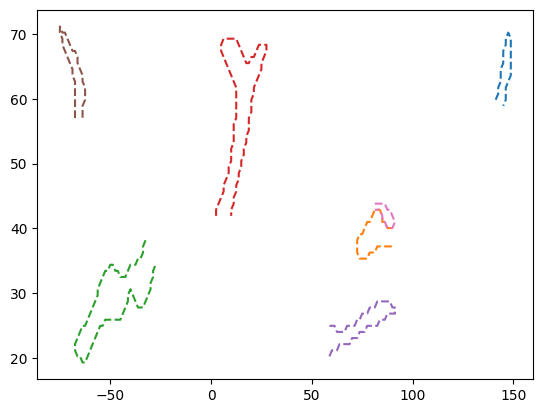

In [569]:
for indexer, este in streamers.group_by("time", "level", "contour"):
    for indexer, este_ in este.group_by("subindex"):
        plt.plot(este_["lon"], este_["lat"], ls="dashed")
    break

In [234]:
este["subindex"]

subindex
u32
0
0
0
0
0
…
0
0
0


In [224]:
for indexer, este in streamers.group_by("time", "level"):
    este = este.drop("index", "index_right").with_row_index("streamer_index").explode("range").rename({"range": "index"}).join(contours, on=["time", "level", "contour", "index"])
    for _, subeste in este.group_by("streamer_index"):
        plt.plot(subeste["lon"], subeste["lat"])
        break
    break

ColumnNotFoundError: "index" not found

In [23]:
este

time,level,contour,index,index_right,forward,max_n,range
datetime[ns],i32,i32,i32,i32,bool,i32,list[i64]
2020-10-18 06:00:00,9,0,51,73,true,144,"[51, 52, … 73]"
2020-10-18 06:00:00,9,0,129,140,true,144,"[129, 130, … 140]"
2020-10-18 06:00:00,9,5,20,66,true,203,"[20, 21, … 66]"
2020-10-18 06:00:00,9,5,50,86,true,203,"[50, 51, … 86]"
2020-10-18 06:00:00,9,5,51,87,true,203,"[51, 52, … 87]"
…,…,…,…,…,…,…,…
2020-10-18 06:00:00,9,21,21,57,true,93,"[21, 22, … 57]"
2020-10-18 06:00:00,9,21,22,56,true,93,"[22, 23, … 56]"
2020-10-18 06:00:00,9,21,23,55,true,93,"[23, 24, … 55]"


In [ ]:
backward = signed_difflon().sum() < 0
index_columns = ["time", "level", "contour"]
index = pl.when(backward).then(pl.col("index").reverse()).otherwise("index")
c = contours.with_columns(backward=signed_difflon().over(index_columns))[:188]
plt.scatter(c["lon"], c["lat"])

In [126]:
contours

contour,level,cyclic,time,lon,lat,side,len,index
i64,i64,bool,datetime[ns],f32,f32,u8,u32,i64
0,9,true,2020-01-01 00:00:00,135.0,18.376963,0,188,0
0,9,true,2020-01-01 00:00:00,136.25,18.376963,0,188,1
0,9,true,2020-01-01 00:00:00,137.5,17.434555,0,188,2
0,9,true,2020-01-01 00:00:00,138.75,17.434555,0,188,3
0,9,true,2020-01-01 00:00:00,140.0,18.376963,0,188,4
…,…,…,…,…,…,…,…,…
18,9,false,2020-12-31 18:00:00,-107.5,77.748688,0,28,23
18,9,false,2020-12-31 18:00:00,-108.75,78.691101,0,28,24
18,9,false,2020-12-31 18:00:00,-110.0,78.691101,0,28,25


(datetime.datetime(2020, 2, 17, 0, 0), 9)
(datetime.datetime(2020, 12, 14, 18, 0), 9)
(datetime.datetime(2020, 1, 27, 18, 0), 9)


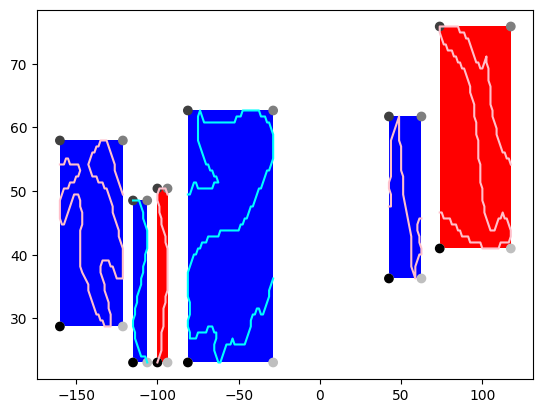

In [53]:
from matplotlib.patches import Rectangle, Polygon
for indexer, overturning in overturnings.group_by(["time", "level"]):
    print(indexer)
    overturning = overturning.explode("side", "points").explode("points")
    time_, level_ = indexer
    ot_sev = overturnings_sev[overturnings_sev.date == time_]
    if len(ot_sev) == 0:
        continue
    fig, ax = plt.subplots()
    for i in range(len(ot_sev)):
        c = ot_sev.iloc[i]
        x, y = c["geometry"].envelope.exterior.coords.xy
        x = np.array(x)
        y = np.array(y)
        color = "blue" if c["orientation"]== "anticyclonic" else "red"
        poly = Polygon(np.vstack([x, y]).T, facecolor=color)
        ax.add_patch(poly)
        plt.scatter(x, y, c=np.arange(len(x)), cmap=colormaps.gray_r)
        
    overturning = overturning.drop("geometry").with_columns(lon=pl.col("points").arr.get(0), lat=pl.col("points").arr.get(1))
    for _, ot in overturning.group_by("index"):
        orientation = ot["orientation"].mode()[0]
        color = "cyan" if orientation == "anticyclonic" else "pink"
        plt.plot(ot["lon"], ot["lat"], color=color)
    
    # plt.figure()
    # c = overturning.filter(pl.col("len") == pl.col("len").max())
    # plt.scatter(c["lon"], c["lat"], c=np.arange(len(c)), cmap=colormaps.gray_r)
    break

In [54]:
ot

time,level,index,points,side,contour,subindex,difflat,difflon,len,inside_index,phys_len,orientation,area,com_x,com_y,zeta,lon,lat
datetime[ns],i32,u32,"array[f32, 2]",u8,i32,u32,f32,f32,u32,i32,f32,str,f32,f32,f32,f32,f32,f32
2020-01-27 18:00:00,9,5,"[73.75, 46.649216]",0,14,8,34.86911,43.75,130,104,1.3267407e7,"""cyclonic""",1.0263e13,55.359539,95.625,11.580453,73.75,46.649216
2020-01-27 18:00:00,9,5,"[75.0, 46.649216]",0,14,8,34.86911,43.75,130,104,1.3267407e7,"""cyclonic""",1.0263e13,55.359539,95.625,11.580453,75.0,46.649216
2020-01-27 18:00:00,9,5,"[76.25, 45.706806]",0,14,8,34.86911,43.75,130,104,1.3267407e7,"""cyclonic""",1.0263e13,55.359539,95.625,11.580453,76.25,45.706806
2020-01-27 18:00:00,9,5,"[77.5, 45.706806]",0,14,8,34.86911,43.75,130,104,1.3267407e7,"""cyclonic""",1.0263e13,55.359539,95.625,11.580453,77.5,45.706806
2020-01-27 18:00:00,9,5,"[78.75, 45.706806]",0,14,8,34.86911,43.75,130,104,1.3267407e7,"""cyclonic""",1.0263e13,55.359539,95.625,11.580453,78.75,45.706806
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2020-01-27 18:00:00,9,5,"[112.5, 56.073299]",0,14,8,34.86911,43.75,130,104,1.3267407e7,"""cyclonic""",1.0263e13,55.359539,95.625,11.580453,112.5,56.073299
2020-01-27 18:00:00,9,5,"[113.75, 56.073299]",0,14,8,34.86911,43.75,130,104,1.3267407e7,"""cyclonic""",1.0263e13,55.359539,95.625,11.580453,113.75,56.073299
2020-01-27 18:00:00,9,5,"[115.0, 55.13089]",0,14,8,34.86911,43.75,130,104,1.3267407e7,"""cyclonic""",1.0263e13,55.359539,95.625,11.580453,115.0,55.13089


(datetime.datetime(2020, 5, 3, 6, 0), 9)


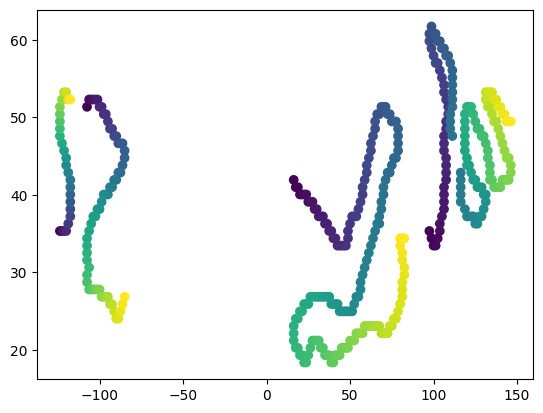

In [ ]:
from matplotlib.patches import Rectangle, Polygon
for indexer, overturning in overturnings.group_by(["time", "level"]):
    print(indexer)
    overturning = overturning.explode("side", "points").explode("points")
    time_, level_ = indexer
    ot_sev = overturnings_sev[overturnings_sev.date == time_]
    if len(ot_sev) == 0:
        continue
    fig, ax = plt.subplots()
    # for i in range(len(ot_sev)):
    #     c = ot_sev.iloc[i]
    #     x, y = c["geometry"].envelope.exterior.coords.xy
    #     x = np.array(x)
    #     y = np.array(y)
    #     color = "blue" if c["orientation"]== "anticyclonic" else "red"
    #     poly = Polygon(np.vstack([x, y]).T, facecolor=color)
    #     ax.add_patch(poly)
    #     plt.scatter(x, y, c=np.arange(len(x)), cmap=colormaps.gray_r)
        
    overturning = overturning.drop("geometry").with_columns(lon=pl.col("points").arr.get(0), lat=pl.col("points").arr.get(1))
    for _, ot in overturning.group_by("index"):
        orientation = ot["orientation"].mode()[0]
        color = "cyan" if orientation == "anticyclonic" else "pink"
        plt.scatter(ot["lon"], ot["lat"], c=np.arange(len(ot)))
    
    # plt.figure()
    # c = overturning.filter(pl.col("len") == pl.col("len").max())
    # plt.scatter(c["lon"], c["lat"], c=np.arange(len(c)), cmap=colormaps.gray_r)
    break

In [107]:
ot["orientation"].unique()[0]

'anticyclonic'

In [43]:
c = ot_sev.iloc[i]
x_, y_ = c["geometry"].envelope.exterior.coords.xy
x_ = np.array(x_).astype(int) % zeta.lon.shape[0]
y_ = np.array(y_).astype(int)
    # x, y = zeta.lon[x_].values, zeta.lat[y_].values
    #     poly = Polygon(np.vstack([x, y]).T)

In [45]:
zeta.lon[x_].values

array([  2.5 , 136.25, 136.25,   2.5 ,   2.5 ], dtype=float32)

In [54]:
x, y = c["geometry"].envelope.exterior.xy

In [55]:
x

array('d', [-142.5, -35.0, -35.0, -142.5, -142.5])

In [34]:
zeta.lat

<xarray.DataArray 'lat' (lat: 74)> Size: 296B
array([10.837696, 11.780105, 12.722513, 13.664922, 14.607329, 15.549738,
       16.492147, 17.434555, 18.376963, 19.319372, 20.26178 , 21.20419 ,
       22.146597, 23.089005, 24.031414, 24.973822, 25.916231, 26.858639,
       27.801046, 28.743456, 29.685863, 30.628273, 31.57068 , 32.51309 ,
       33.455498, 34.397907, 35.340313, 36.282722, 37.225132, 38.167538,
       39.109947, 40.052357, 40.994766, 41.937172, 42.87958 , 43.82199 ,
       44.764397, 45.706806, 46.649216, 47.59162 , 48.53403 , 49.47644 ,
       50.41885 , 51.361256, 52.303665, 53.246075, 54.18848 , 55.13089 ,
       56.0733  , 57.015705, 57.958115, 58.900524, 59.842934, 60.78534 ,
       61.72775 , 62.67016 , 63.612564, 64.55498 , 65.49738 , 66.43979 ,
       67.3822  , 68.32461 , 69.26701 , 70.20943 , 71.15183 , 72.09424 ,
       73.03665 , 73.97906 , 74.92146 , 75.86388 , 76.80628 , 77.74869 ,
       78.6911  , 79.63351 ], dtype=float32)
Coordinates:
  * lat      (lat) float32 296B 10.84 11.78 12.72 13.66 ... 77.75 78.69 79.63

In [17]:
np.vstack([x, y]).T

array([[-170.    ,   33.4555],
       [  28.75  ,   33.4555],
       [  28.75  ,   67.3822],
       [-170.    ,   67.3822],
       [-170.    ,   33.4555]], dtype=float32)

In [ ]:
c["geometry"].envelope.exterior.coords.xy

(array('d', [-180.0, 178.75, 178.75, -180.0, -180.0]),
 array('d', [50.41884994506836, 50.41884994506836, 76.80628204345703, 76.80628204345703, 50.41884994506836]))

In [ ]:
ot_sev

,date,level,com,mean_var,intensity,event_area,orientation,geometry
1837,2020-05-19 06:00:00,9,"[-93.75, 44.764397]",10.10,0.0,55225156.0,anticyclonic,"POLYGON ((-27.5 24.03141, -27.5 76.80628, -158..."
1838,2020-05-19 06:00:00,9,"[133.75, 41.937172]",9.61,0.0,144080688.0,cyclonic,"MULTIPOLYGON (((178.75 74.92146, 178.75 19.319..."


In [ ]:
np.array(x_)

array([121., 120., 119., 118., 117., 116., 115., 114., 113., 113., 113.,
       114., 115., 116., 117., 118., 119., 120., 121., 122., 122., 123.,
       123., 122.])